# Part C: Results and Figures
# Introduction
This notebook contains the code used to evaluate the results and generate some of the figures in the paper:  "Evaluating the E-OBS meteorological forcing data quality for large-sample hydrology studies in Europe" paper by Clerc-Schwarzenbach and do Nascimento et al. (in review). To be able to run this notebook, please ensure that you have downloaded the acompanying data of the paper. All links can be found in the data section of the paper.

Author: Thiago Nascimento (thiago.nascimento@eawag.ch)

# Import modules

In [1]:
import pandas as pd
import numpy as np
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib as mpl
import warnings
from sklearn.preprocessing import LabelEncoder
warnings.simplefilter(action='ignore', category=Warning)


# Configurations

In [2]:
# Only editable variables:
# Relative path to your local directory
PATH = "../.."

# Set the directory:
os.chdir(PATH)

path_estreams = r'/Users/nascimth/Documents/data/EStreams'

# Import data

### - Network information

In [3]:
network_estreams = pd.read_csv(path_estreams+'/streamflow_gauges/estreams_gauging_stations.csv', encoding='utf-8')
network_estreams.set_index("basin_id", inplace = True)

# Convert 'date_column' and 'time_column' to datetime
network_estreams['start_date'] = pd.to_datetime(network_estreams['start_date'])
network_estreams['end_date'] = pd.to_datetime(network_estreams['end_date'])

network_estreams

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,num_continuous_days,num_days_gaps,num_days_reliable,num_days_noflag,num_days_suspect,gauge_flag,duplicated_suspect,watershed_group,gauges_upstream,nested_catchments
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000001,200014,Bangs,AT,AT_EHYD,Rhein,9.534835,47.273748,9.534835,47.273748,420,...,9497,0.0,0.0,9497.0,0.0,B,['CH000197'],1,16,"['AT000001', 'CH000010', 'CH000046', 'CH000048..."
AT000002,200048,Schruns (Vonbunweg),AT,AT_EHYD,Litz,9.913677,47.080301,9.913677,47.080301,673,...,23103,0.0,0.0,23103.0,0.0,B,['CH000221'],1,1,['AT000002']
AT000003,231662,Loruens-Aeule,AT,AT_EHYD,Ill,9.847765,47.132821,9.847765,47.132821,579,...,13513,0.0,0.0,13513.0,0.0,B,['CH000215'],1,2,"['AT000002', 'AT000003', 'CH000221']"
AT000004,200592,Kloesterle (OEBB),AT,AT_EHYD,Alfenz,10.061843,47.128994,10.061843,47.128994,1014,...,8765,0.0,0.0,8765.0,0.0,B,['CH000227'],1,1,['AT000004']
AT000005,200097,Buers (Bruecke L82),AT,AT_EHYD,Alvier,9.802668,47.150770,9.802668,47.150770,564,...,10957,0.0,0.0,10957.0,0.0,B,['CH000214'],1,3,"['AT000005', 'CH000214']"
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UAGR0017,6682300,BASHTANOVKA,UA,UA_GRDC,KACHA,33.894739,44.691884,33.900000,44.683333,NaN,...,3652,0.0,0.0,3652.0,0.0,B,NaN,1988,1,['UAGR0017']
UAGR0018,6682500,YALTA,UA,UA_GRDC,DERE-KIOY,34.166667,44.500000,34.166667,44.500000,16,...,3652,0.0,0.0,3652.0,0.0,B,NaN,1989,1,['UAGR0018']
UAGR0019,6683010,PIONERSKOE,UA,UA_GRDC,SALHYR,34.199841,44.887685,34.200000,44.883333,307,...,3652,0.0,0.0,3652.0,0.0,B,NaN,1990,1,['UAGR0019']


In [4]:
estreams_signatures = pd.read_csv(path_estreams+'/hydroclimatic_signatures/estreams_hydrometeo_signatures.csv', encoding='utf-8')
estreams_signatures.set_index("Unnamed: 0", inplace = True)
estreams_signatures.index.name = "basin_id"

# Mapping dictionary for reclassification
time_mapping = {
    'Fall': 1, 
    'Winter': 2,  
    'Spring': 3,  
    'Summer': 4, 
}

# Reclassify time classes using the mapping dictionary
estreams_signatures['hp_time'] = estreams_signatures['hp_time'].map(time_mapping)
estreams_signatures['lp_time'] = estreams_signatures['lp_time'].map(time_mapping)

# Subset the signatures to be used (only variables, not dates and number of measurments):
estreams_signatures = estreams_signatures.iloc[:, 0:-6]
estreams_signatures

,q_mean,q_runoff_ratio,q_elas_Sankarasubramanian,slope_sawicz,baseflow_index,hfd_mean,hfd_std,q_5,q_95,hq_freq,...,aridity_pm,aridity_mk,p_seasonality,frac_snow,hp_freq,hp_dur,hp_time,lp_freq,lp_dur,lp_time
basin_id,,,,,,,,,,,,,,,,,,,,,
AT000001,2.824,0.752,1.235,1.505,0.760,237.600,12.858,1.029,6.607,0.077,...,0.430,0.463,0.315,0.324,13.280,1.176,4.0,199.864,3.563,1.0
AT000002,3.898,1.083,0.920,2.467,0.720,247.952,10.932,0.980,10.727,0.964,...,0.428,0.468,0.359,0.331,16.518,1.201,4.0,208.028,3.639,1.0
AT000003,0.915,0.259,1.403,0.979,0.687,233.361,27.141,0.404,2.819,6.136,...,0.446,0.484,0.370,0.329,16.260,1.199,4.0,208.178,3.649,1.0
AT000004,5.079,1.313,0.328,2.188,0.747,242.783,10.736,1.499,13.295,0.042,...,0.428,0.453,0.342,0.380,16.847,1.210,4.0,209.780,3.653,1.0
AT000005,3.319,0.811,0.908,1.967,0.756,239.207,14.642,1.064,7.692,0.233,...,0.416,0.436,0.330,0.271,15.825,1.186,4.0,203.069,3.567,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
UAGR0017,0.150,0.080,-1.875,NaN,0.354,189.111,72.114,0.000,0.797,81.511,...,NaN,1.103,-0.274,0.137,21.940,1.260,2.0,268.738,5.632,4.0
UAGR0018,0.475,0.219,2.471,NaN,0.207,160.444,42.925,0.000,3.631,60.508,...,NaN,0.971,-0.340,0.203,20.824,1.247,2.0,262.072,5.363,4.0
UAGR0019,0.312,0.155,2.972,NaN,0.354,184.667,59.422,0.000,1.412,127.517,...,NaN,0.971,-0.158,0.182,21.805,1.248,2.0,265.087,5.419,4.0


In [5]:
estreams_meteodensity = pd.read_csv(path_estreams+'//attributes/static_attributes/estreams_meteorology_density.csv', encoding='utf-8')
estreams_meteodensity.set_index("basin_id", inplace = True)

## Here we select only these variables as representative:
estreams_meteodensity = estreams_meteodensity[["stations_num_p_mean", "stations_num_t_mean"]]

estreams_meteodensity.head()

,stations_num_p_mean,stations_num_t_mean
basin_id,,
AT000001,22.0,23.0
AT000002,14.0,13.0
AT000003,18.0,18.0
AT000004,7.0,8.0
AT000005,10.0,10.0


In [6]:
estreams_landcover = pd.read_csv(path_estreams+'//attributes/temporal_attributes/estreams_landcover_attributes.csv', encoding='utf-8')
estreams_landcover.set_index("basin_id", inplace = True)
estreams_landcover

# We have more than 20 classes, so it is better if we aggregate the classes in more representative ones:
# * 1. Urban, 2. Non irrigated aggriculture, 3. Irrigated aggriculture, 4. grassland and 5. forests

def aggregate_columns(df, years):
    # Initialize a dictionary to store aggregated columns
    aggregated_columns = {}

    # Iterate through each year
    for year in years:
        # Iterate through each column in the DataFrame
        for column in df.columns:
            # Check if the column name contains the specified year and the number is between 300 and 315 for forest
            if f'_{year}_' in column and 300 <= int(column.split('_')[-1]) < 315:
                prefix = '_'.join(column.split('_')[:-1]) + "_forest"
                if prefix in aggregated_columns:
                    aggregated_columns[prefix].append(column)
                else:
                    aggregated_columns[prefix] = [column]
            # Check if the column name contains the specified year and the number is between 315 and 400 for grass
            elif f'_{year}_' in column and 315 <= int(column.split('_')[-1]) < 400:
                prefix = '_'.join(column.split('_')[:-1]) + "_grass"
                if prefix in aggregated_columns:
                    aggregated_columns[prefix].append(column)
                else:
                    aggregated_columns[prefix] = [column]
            # Check if the column name contains the specified year and the number is between 200 and 300 for agriculture
            elif f'_{year}_' in column and 212 <= int(column.split('_')[-1]) < 300:
                prefix = '_'.join(column.split('_')[:-1]) + "_Agric"
                if prefix in aggregated_columns:
                    aggregated_columns[prefix].append(column)
                else:
                    aggregated_columns[prefix] = [column]
        
            # Check if the column name contains the specified year and the number is between 200 and 300 for agriculture
            elif f'_{year}_' in column and 200 <= int(column.split('_')[-1]) < 212:
                prefix = '_'.join(column.split('_')[:-1]) + "_NonIrriAgri"
                if prefix in aggregated_columns:
                    aggregated_columns[prefix].append(column)
                else:
                    aggregated_columns[prefix] = [column]

             # Check if the column name contains the specified year and the number is between 200 and 300 for agriculture
            elif f'_{year}_' in column and 111 <= int(column.split('_')[-1]) <= 124:
                prefix = '_'.join(column.split('_')[:-1]) + "_urban"
                if prefix in aggregated_columns:
                    aggregated_columns[prefix].append(column)
                else:
                    aggregated_columns[prefix] = [column]                   
    # Iterate through the aggregated_columns dictionary and create new aggregated columns
    for prefix, columns in aggregated_columns.items():
        # Aggregate the columns by summing them along the columns axis
        df[prefix] = df[columns].sum(axis=1)
        # Drop the original columns
        df.drop(columns, axis=1, inplace=True)

# List of years to iterate over
years = [1990, 2000, 2006, 2012, 2018]

# Call the function to aggregate columns for each year
aggregate_columns(estreams_landcover, years)


# Filter only the columns already resampled:
estreams_landcover = estreams_landcover.iloc[:, -25:]

# Subset only one year to avoid co-correlation
estreams_landcover = estreams_landcover[["lulc_2006_urban", "lulc_2006_NonIrriAgri", "lulc_2006_Agric", "lulc_2006_forest", 
                                         "lulc_2006_grass"]]
estreams_landcover["lulc_2006_agriculture"] = estreams_landcover.lulc_2006_NonIrriAgri + estreams_landcover.lulc_2006_Agric

estreams_landcover.head()

,lulc_2006_urban,lulc_2006_NonIrriAgri,lulc_2006_Agric,lulc_2006_forest,lulc_2006_grass,lulc_2006_agriculture
basin_id,,,,,,
AT000001,0.020,0.019,0.108,0.268,0.581,0.127
AT000002,0.029,0.000,0.051,0.331,0.577,0.051
AT000003,0.031,0.000,0.040,0.269,0.647,0.040
AT000004,0.023,0.000,0.031,0.177,0.739,0.031
AT000005,0.017,0.000,0.023,0.283,0.624,0.023


In [7]:
estreams_topography = pd.read_csv(path_estreams+'//attributes/static_attributes/estreams_topography_attributes.csv', encoding='utf-8')
estreams_topography.set_index("basin_id", inplace = True)
estreams_topography

,ele_mt_max,ele_mt_mean,ele_mt_min,slp_dg_mean,flat_area_fra,steep_area_fra,elon_ratio,strm_dens
basin_id,,,,,,,,
AT000001,3555.408,1874.076,420.622,24.122,3.395,78.590,0.612,0.151
AT000002,2803.984,1773.178,674.209,26.095,0.463,87.662,0.539,0.151
AT000003,3293.054,1843.003,583.510,25.735,1.497,82.952,0.577,0.141
AT000004,2878.033,1890.429,1022.324,27.324,0.351,88.023,0.587,0.095
AT000005,2938.964,1772.902,567.275,28.647,1.719,83.629,0.612,0.134
...,...,...,...,...,...,...,...,...
UAGR0017,1537.278,564.291,161.399,11.810,4.283,24.393,0.634,0.129
UAGR0018,1511.835,749.565,16.793,19.438,2.114,61.735,0.621,0.024
UAGR0019,1449.416,653.127,306.877,9.655,17.055,20.545,0.739,0.112


In [8]:
estreams_hydrology = pd.read_csv(path_estreams+'//attributes/static_attributes/estreams_hydrology_attributes.csv', encoding='utf-8')
estreams_hydrology.set_index("basin_id", inplace = True)

# Here we select only these variables as representative
estreams_hydrology = estreams_hydrology[["dam_num", "res_num", "lakes_num", "lakes_tot_area", "lakes_tot_vol"]]
estreams_hydrology

,dam_num,res_num,lakes_num,lakes_tot_area,lakes_tot_vol
basin_id,,,,,
AT000001,23.0,10.0,10.0,6.62,542.33
AT000002,0.0,0.0,0.0,0.00,0.00
AT000003,4.0,4.0,3.0,1.46,12.91
AT000004,0.0,0.0,0.0,0.00,0.00
AT000005,1.0,1.0,1.0,0.89,8.27
...,...,...,...,...,...
UAGR0017,0.0,0.0,1.0,1.43,16.43
UAGR0018,0.0,0.0,0.0,0.00,0.00
UAGR0019,0.0,0.0,1.0,0.31,1.54


In [9]:
estreams_soil = pd.read_csv(path_estreams+'/attributes/static_attributes/estreams_soil_attributes.csv', encoding='utf-8')
estreams_soil.set_index("basin_id", inplace = True)

# Here we select only these variables as representative
estreams_soil = estreams_soil[['root_dep_mean', 'root_dep_max', 'root_dep_min',
       'soil_tawc_mean', 'soil_fra_sand_mean', 'soil_fra_silt_mean',
       'soil_fra_clay_mean', 'soil_fra_grav_mean', 'soil_bd_mean','soil_oc_mean']]

estreams_soil

,root_dep_mean,root_dep_max,root_dep_min,soil_tawc_mean,soil_fra_sand_mean,soil_fra_silt_mean,soil_fra_clay_mean,soil_fra_grav_mean,soil_bd_mean,soil_oc_mean
basin_id,,,,,,,,,,
AT000001,81.571,130.0,0.0,28.738,58.196,16.337,7.973,9.062,1.303,1.218
AT000002,58.600,70.0,30.0,46.474,54.920,29.650,15.430,8.140,1.502,1.820
AT000003,51.660,130.0,0.0,45.044,49.262,30.836,16.883,10.294,1.425,1.714
AT000004,49.412,70.0,30.0,49.256,39.956,40.088,19.956,13.044,1.409,1.771
AT000005,31.781,100.0,0.0,44.098,39.795,38.151,20.685,17.658,1.384,1.836
...,...,...,...,...,...,...,...,...,...,...
UAGR0017,128.620,130.0,40.0,51.371,23.184,29.245,47.571,9.939,1.246,1.198
UAGR0018,73.061,130.0,40.0,64.165,30.592,39.122,30.286,7.469,1.066,2.340
UAGR0019,130.000,130.0,130.0,51.029,23.115,29.123,47.761,10.049,1.251,1.178


In [10]:
estreams_soil = pd.read_csv(path_estreams+'/attributes/static_attributes/estreams_soil_attributes.csv', encoding='utf-8')
estreams_soil.set_index("basin_id", inplace = True)

# Here we select only these variables as representative
estreams_soil = estreams_soil[['root_dep_mean', 'root_dep_max', 'root_dep_min',
       'soil_tawc_mean', 'soil_fra_sand_mean', 'soil_fra_silt_mean',
       'soil_fra_clay_mean', 'soil_fra_grav_mean', 'soil_bd_mean','soil_oc_mean']]

estreams_soil

,root_dep_mean,root_dep_max,root_dep_min,soil_tawc_mean,soil_fra_sand_mean,soil_fra_silt_mean,soil_fra_clay_mean,soil_fra_grav_mean,soil_bd_mean,soil_oc_mean
basin_id,,,,,,,,,,
AT000001,81.571,130.0,0.0,28.738,58.196,16.337,7.973,9.062,1.303,1.218
AT000002,58.600,70.0,30.0,46.474,54.920,29.650,15.430,8.140,1.502,1.820
AT000003,51.660,130.0,0.0,45.044,49.262,30.836,16.883,10.294,1.425,1.714
AT000004,49.412,70.0,30.0,49.256,39.956,40.088,19.956,13.044,1.409,1.771
AT000005,31.781,100.0,0.0,44.098,39.795,38.151,20.685,17.658,1.384,1.836
...,...,...,...,...,...,...,...,...,...,...
UAGR0017,128.620,130.0,40.0,51.371,23.184,29.245,47.571,9.939,1.246,1.198
UAGR0018,73.061,130.0,40.0,64.165,30.592,39.122,30.286,7.469,1.066,2.340
UAGR0019,130.000,130.0,130.0,51.029,23.115,29.123,47.761,10.049,1.251,1.178


In [11]:
estreams_vegetation= pd.read_csv(path_estreams+"//attributes/static_attributes/estreams_vegetation_attributes.csv", encoding='utf-8')
estreams_vegetation.set_index("basin_id", inplace = True)

# Here we select only these two variables as representative
estreams_vegetation = estreams_vegetation[["lai_mean", "ndvi_mean"]]
estreams_vegetation

,lai_mean,ndvi_mean
basin_id,,
AT000001,0.092,0.329
AT000002,0.089,0.342
AT000003,0.087,0.313
AT000004,0.073,0.276
AT000005,0.086,0.311
...,...,...
UAGR0017,0.195,0.599
UAGR0018,0.152,0.576
UAGR0019,0.145,0.535


In [12]:
estreams_snowcover = pd.read_csv(path_estreams+"//attributes/static_attributes/estreams_snowcover_attributes.csv", encoding='utf-8')
estreams_snowcover.set_index("basin_id", inplace = True)

# Here we select only these two variables as representative
estreams_snowcover = estreams_snowcover[["sno_cov_mean"]]
estreams_snowcover

,sno_cov_mean
basin_id,
AT000001,33.844
AT000002,36.284
AT000003,36.927
AT000004,40.210
AT000005,34.486
...,...
UAGR0017,3.805
UAGR0018,6.159
UAGR0019,4.928


In [15]:
performances = pd.read_csv(r"data/performances.txt", sep="\t")
performances.set_index("id", inplace=True)

performances

,ptq_camels/evap_camels,pt_q_camels/evap_estreams,p_t_estreams_q/evap_estreams,pt_q_camels/evap_camels,p_estreams_tq/evap_estreams
id,,,,,
CH000010,0.865025,0.848061,0.852583,0.849539,0.853620
CH000011,0.898634,0.862240,0.906206,0.868377,0.862240
CH000013,0.933737,0.874643,0.930635,0.888077,0.877099
CH000015,0.916430,0.903032,0.915778,0.898679,0.901525
CH000019,0.906401,0.799762,0.905491,0.807781,0.803233
...,...,...,...,...,...
GB000665,0.924506,0.753328,0.914888,0.768492,0.762375
GB000668,0.897872,0.739942,0.875703,0.746211,0.762591
SE000014,0.924360,0.928001,0.921035,0.913352,0.926494


In [16]:
hydmet = pd.read_csv("data/hydmet.txt", sep="\t")
hydmet.set_index("id", inplace=True)
hydmet['aridity_estreams'] = hydmet['Epot_sum_Estr']/ hydmet['P_sum_Estr']
hydmet['aridity_camels'] = hydmet['Epot_sum_CAM']/ hydmet['P_sum_CAM']

hydmet

,P_sum_CAM,P_sum_Estr,rel_diff_P,T_mean_CAM,T_mean_Estr,T_diff,Epot_sum_CAM,Epot_sum_Estr,rel_diff_Epot,aridity_estreams,aridity_camels
id,,,,,,,,,,,
CH000010,1526.154000,1595.6490,4.553603,2.167109,2.091775,-0.075333,496.207500,497.815000,0.323957,0.311983,0.325136
CH000011,1189.510500,1082.9845,-8.955448,9.085299,8.710934,-0.374366,669.358500,812.830500,21.434254,0.750547,0.562718
CH000013,1392.200000,1212.5375,-12.904935,8.152930,8.569173,0.416244,577.401000,730.290500,26.478912,0.602283,0.414740
CH000015,1669.151500,1594.7670,-4.456426,1.846719,1.887781,0.041062,502.166500,487.497500,-2.921143,0.305686,0.300851
CH000019,1548.184000,1225.8155,-20.822363,6.807710,6.989047,0.181337,596.153000,721.778000,21.072611,0.588815,0.385066
...,...,...,...,...,...,...,...,...,...,...,...
GB000665,2680.491500,2200.4655,-17.908134,6.812886,7.188957,0.376071,392.887500,507.985361,29.295374,0.230854,0.146573
GB000668,1153.528000,988.1350,-14.338013,7.501036,7.691843,0.190806,408.729000,486.075753,18.923725,0.491912,0.354330
SE000014,845.669563,745.6875,-11.822829,6.698359,6.610286,-0.088073,830.500765,607.106500,-26.898743,0.814157,0.982063


In [17]:
# Concatenate horizontally
network_basins = pd.concat([network_estreams, performances, estreams_signatures, estreams_topography,
                                           estreams_soil, estreams_vegetation, estreams_landcover,
                                           estreams_hydrology, estreams_snowcover, estreams_meteodensity, hydmet], axis=1)

network_basins = network_basins.loc[performances.index]

network_basins

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,P_sum_Estr,rel_diff_P,T_mean_CAM,T_mean_Estr,T_diff,Epot_sum_CAM,Epot_sum_Estr,rel_diff_Epot,aridity_estreams,aridity_camels
id,,,,,,,,,,,,,,,,,,,,,
CH000010,2033,Ilanz,CH,CH_CAMELS,Vorderrhein,9.2100,46.7800,9.2100,46.7800,700,...,1595.6490,4.553603,2.167109,2.091775,-0.075333,496.207500,497.815000,0.323957,0.311983,0.325136
CH000011,2034,Payerne-Caserne_d'aviation,CH,CH_CAMELS,Broye,6.9400,46.8400,6.9400,46.8400,444,...,1082.9845,-8.955448,9.085299,8.710934,-0.374366,669.358500,812.830500,21.434254,0.750547,0.562718
CH000013,2044,Andelfingen,CH,CH_CAMELS,Thur,8.6800,47.6000,8.6800,47.6000,363,...,1212.5375,-12.904935,8.152930,8.569173,0.416244,577.401000,730.290500,26.478912,0.602283,0.414740
CH000015,2056,Seedorf,CH,CH_CAMELS,Reuss,8.6200,46.8800,8.6200,46.8800,440,...,1594.7670,-4.456426,1.846719,1.887781,0.041062,502.166500,487.497500,-2.921143,0.305686,0.300851
CH000019,2070,Emmenmatt,CH,CH_CAMELS,Emme,7.7500,46.9500,7.7500,46.9500,643,...,1225.8155,-20.822363,6.807710,6.989047,0.181337,596.153000,721.778000,21.072611,0.588815,0.385066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB000665,93001,Carron at New Kelso,GB,GB_NRFA,Carron at New Kelso,-5.4300,57.4300,-5.4300,57.4300,5.6,...,2200.4655,-17.908134,6.812886,7.188957,0.376071,392.887500,507.985361,29.295374,0.230854,0.146573
GB000668,96001,Halladale at Halladale,GB,GB_NRFA,Halladale at Halladale,-3.9000,58.4800,-3.9000,58.4800,23.2,...,988.1350,-14.338013,7.501036,7.691843,0.190806,408.729000,486.075753,18.923725,0.491912,0.354330
SE000014,1236,SUNDSTORP,SE,SE_SMHI,LIDAN,13.0397,58.3222,13.0397,58.3222,NaN,...,745.6875,-11.822829,6.698359,6.610286,-0.088073,830.500765,607.106500,-26.898743,0.814157,0.982063


In [18]:
runoff_ratios_camels_and_estreams_2682_filtered_rr = pd.read_csv(r"data/runoff_ratios_camels_and_estreams_2682_filtered_rr.txt", sep="\t")
runoff_ratios_camels_and_estreams_2682_filtered_rr.set_index("basin_id", inplace=True)

runoff_ratios_camels_and_estreams_2682_filtered_rr

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,q_mean,p_mean,lakes_num,lakes_depth_mean,lakes_depth_mean_norm,q_mean_yr,p_mean_yr,norm_ups_cap,Q_cam_by_P_estr,Q_cam_by_P_cam
basin_id,,,,,,,,,,,,,,,,,,,,,
CH000010,2033,Ilanz,CH,CH_CAMELS,Vorderrhein,9.2100,46.7800,9.2100,46.7800,700,...,3.688,4.288,3.0,81.595745,198.137712,1346.120,1565.120,0.126596,0.834265,0.872254
CH000011,2034,Payerne-Caserne_d'aviation,CH,CH_CAMELS,Broye,6.9400,46.8400,6.9400,46.8400,444,...,1.618,3.136,0.0,NaN,0.000000,590.570,1144.640,0.000000,0.521699,0.474978
CH000013,2044,Andelfingen,CH,CH_CAMELS,Thur,8.6800,47.6000,8.6800,47.6000,363,...,2.375,3.278,2.0,3.341463,0.804983,866.875,1196.470,0.000673,0.717178,0.624626
CH000015,2056,Seedorf,CH,CH_CAMELS,Reuss,8.6200,46.8800,8.6200,46.8800,440,...,4.459,4.340,2.0,108.602151,121.193649,1627.535,1584.100,0.076506,1.005801,0.960978
CH000019,2070,Emmenmatt,CH,CH_CAMELS,Emme,7.7500,46.9500,7.7500,46.9500,643,...,2.292,3.449,0.0,NaN,0.000000,836.580,1258.885,0.000000,0.701906,0.555753
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB000665,93001,Carron at New Kelso,GB,GB_NRFA,Carron at New Kelso,-5.4300,57.4300,-5.4300,57.4300,5.6,...,6.642,5.657,2.0,7.290076,68.616673,2424.330,2064.805,0.033232,1.068201,0.876906
GB000668,96001,Halladale at Halladale,GB,GB_NRFA,Halladale at Halladale,-3.9000,58.4800,-3.9000,58.4800,23.2,...,2.222,2.599,3.0,3.041667,7.533112,811.030,948.635,0.007941,0.829819,0.710839
SE000014,1236,SUNDSTORP,SE,SE_SMHI,LIDAN,13.0397,58.3222,13.0397,58.3222,NaN,...,0.820,1.888,2.0,2.347826,3.255513,299.300,689.120,0.004724,0.418766,0.369256


In [19]:
network_basins = network_basins.loc[runoff_ratios_camels_and_estreams_2682_filtered_rr.index]
network_basins

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,P_sum_Estr,rel_diff_P,T_mean_CAM,T_mean_Estr,T_diff,Epot_sum_CAM,Epot_sum_Estr,rel_diff_Epot,aridity_estreams,aridity_camels
basin_id,,,,,,,,,,,,,,,,,,,,,
CH000010,2033,Ilanz,CH,CH_CAMELS,Vorderrhein,9.2100,46.7800,9.2100,46.7800,700,...,1595.6490,4.553603,2.167109,2.091775,-0.075333,496.207500,497.815000,0.323957,0.311983,0.325136
CH000011,2034,Payerne-Caserne_d'aviation,CH,CH_CAMELS,Broye,6.9400,46.8400,6.9400,46.8400,444,...,1082.9845,-8.955448,9.085299,8.710934,-0.374366,669.358500,812.830500,21.434254,0.750547,0.562718
CH000013,2044,Andelfingen,CH,CH_CAMELS,Thur,8.6800,47.6000,8.6800,47.6000,363,...,1212.5375,-12.904935,8.152930,8.569173,0.416244,577.401000,730.290500,26.478912,0.602283,0.414740
CH000015,2056,Seedorf,CH,CH_CAMELS,Reuss,8.6200,46.8800,8.6200,46.8800,440,...,1594.7670,-4.456426,1.846719,1.887781,0.041062,502.166500,487.497500,-2.921143,0.305686,0.300851
CH000019,2070,Emmenmatt,CH,CH_CAMELS,Emme,7.7500,46.9500,7.7500,46.9500,643,...,1225.8155,-20.822363,6.807710,6.989047,0.181337,596.153000,721.778000,21.072611,0.588815,0.385066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB000665,93001,Carron at New Kelso,GB,GB_NRFA,Carron at New Kelso,-5.4300,57.4300,-5.4300,57.4300,5.6,...,2200.4655,-17.908134,6.812886,7.188957,0.376071,392.887500,507.985361,29.295374,0.230854,0.146573
GB000668,96001,Halladale at Halladale,GB,GB_NRFA,Halladale at Halladale,-3.9000,58.4800,-3.9000,58.4800,23.2,...,988.1350,-14.338013,7.501036,7.691843,0.190806,408.729000,486.075753,18.923725,0.491912,0.354330
SE000014,1236,SUNDSTORP,SE,SE_SMHI,LIDAN,13.0397,58.3222,13.0397,58.3222,NaN,...,745.6875,-11.822829,6.698359,6.610286,-0.088073,830.500765,607.106500,-26.898743,0.814157,0.982063


In [20]:
network_basins.groupby("gauge_country").count()

,gauge_id,gauge_name,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,area_official,...,P_sum_Estr,rel_diff_P,T_mean_CAM,T_mean_Estr,T_diff,Epot_sum_CAM,Epot_sum_Estr,rel_diff_Epot,aridity_estreams,aridity_camels
gauge_country,,,,,,,,,,,,,,,,,,,,,
CH,133,133,133,133,133,133,133,133,133,133,...,133,133,133,133,133,133,133,133,133,133
CZ,244,244,244,244,244,244,244,244,0,244,...,244,244,244,244,244,244,244,244,244,244
DE,986,986,986,832,986,986,986,986,769,981,...,986,986,986,986,986,986,986,986,986,986
DK,120,120,120,120,120,120,120,120,0,120,...,120,120,120,120,120,120,120,120,120,120
ES,211,211,211,0,211,211,211,211,211,211,...,211,211,211,211,211,211,211,211,211,211
FR,496,496,496,496,496,496,496,496,491,492,...,496,496,496,496,496,496,496,496,496,496
GB,489,489,489,489,489,489,489,489,489,489,...,489,489,489,489,489,489,489,489,489,489
SE,3,3,3,3,3,3,3,3,0,3,...,3,3,3,3,3,3,3,3,3,3


In [21]:
network_basins.index.name="basin_id"

network_basins

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,P_sum_Estr,rel_diff_P,T_mean_CAM,T_mean_Estr,T_diff,Epot_sum_CAM,Epot_sum_Estr,rel_diff_Epot,aridity_estreams,aridity_camels
basin_id,,,,,,,,,,,,,,,,,,,,,
CH000010,2033,Ilanz,CH,CH_CAMELS,Vorderrhein,9.2100,46.7800,9.2100,46.7800,700,...,1595.6490,4.553603,2.167109,2.091775,-0.075333,496.207500,497.815000,0.323957,0.311983,0.325136
CH000011,2034,Payerne-Caserne_d'aviation,CH,CH_CAMELS,Broye,6.9400,46.8400,6.9400,46.8400,444,...,1082.9845,-8.955448,9.085299,8.710934,-0.374366,669.358500,812.830500,21.434254,0.750547,0.562718
CH000013,2044,Andelfingen,CH,CH_CAMELS,Thur,8.6800,47.6000,8.6800,47.6000,363,...,1212.5375,-12.904935,8.152930,8.569173,0.416244,577.401000,730.290500,26.478912,0.602283,0.414740
CH000015,2056,Seedorf,CH,CH_CAMELS,Reuss,8.6200,46.8800,8.6200,46.8800,440,...,1594.7670,-4.456426,1.846719,1.887781,0.041062,502.166500,487.497500,-2.921143,0.305686,0.300851
CH000019,2070,Emmenmatt,CH,CH_CAMELS,Emme,7.7500,46.9500,7.7500,46.9500,643,...,1225.8155,-20.822363,6.807710,6.989047,0.181337,596.153000,721.778000,21.072611,0.588815,0.385066
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB000665,93001,Carron at New Kelso,GB,GB_NRFA,Carron at New Kelso,-5.4300,57.4300,-5.4300,57.4300,5.6,...,2200.4655,-17.908134,6.812886,7.188957,0.376071,392.887500,507.985361,29.295374,0.230854,0.146573
GB000668,96001,Halladale at Halladale,GB,GB_NRFA,Halladale at Halladale,-3.9000,58.4800,-3.9000,58.4800,23.2,...,988.1350,-14.338013,7.501036,7.691843,0.190806,408.729000,486.075753,18.923725,0.491912,0.354330
SE000014,1236,SUNDSTORP,SE,SE_SMHI,LIDAN,13.0397,58.3222,13.0397,58.3222,NaN,...,745.6875,-11.822829,6.698359,6.610286,-0.088073,830.500765,607.106500,-26.898743,0.814157,0.982063


In [22]:
network_basins["diff"] = network_basins['pt_q_camels/evap_estreams']-network_basins['ptq_camels/evap_camels']
network_basins['estreams_kges'] = network_basins['pt_q_camels/evap_estreams']
network_basins["camels_kges"] = network_basins['ptq_camels/evap_camels']
network_basins['aridity_estreams'] = hydmet['aridity_estreams']
network_basins['aridity_camels'] = hydmet['aridity_camels'] 

network_basins

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,T_mean_Estr,T_diff,Epot_sum_CAM,Epot_sum_Estr,rel_diff_Epot,aridity_estreams,aridity_camels,diff,estreams_kges,camels_kges
basin_id,,,,,,,,,,,,,,,,,,,,,
CH000010,2033,Ilanz,CH,CH_CAMELS,Vorderrhein,9.2100,46.7800,9.2100,46.7800,700,...,2.091775,-0.075333,496.207500,497.815000,0.323957,0.311983,0.325136,-0.016964,0.848061,0.865025
CH000011,2034,Payerne-Caserne_d'aviation,CH,CH_CAMELS,Broye,6.9400,46.8400,6.9400,46.8400,444,...,8.710934,-0.374366,669.358500,812.830500,21.434254,0.750547,0.562718,-0.036394,0.862240,0.898634
CH000013,2044,Andelfingen,CH,CH_CAMELS,Thur,8.6800,47.6000,8.6800,47.6000,363,...,8.569173,0.416244,577.401000,730.290500,26.478912,0.602283,0.414740,-0.059094,0.874643,0.933737
CH000015,2056,Seedorf,CH,CH_CAMELS,Reuss,8.6200,46.8800,8.6200,46.8800,440,...,1.887781,0.041062,502.166500,487.497500,-2.921143,0.305686,0.300851,-0.013398,0.903032,0.916430
CH000019,2070,Emmenmatt,CH,CH_CAMELS,Emme,7.7500,46.9500,7.7500,46.9500,643,...,6.989047,0.181337,596.153000,721.778000,21.072611,0.588815,0.385066,-0.106639,0.799762,0.906401
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
GB000665,93001,Carron at New Kelso,GB,GB_NRFA,Carron at New Kelso,-5.4300,57.4300,-5.4300,57.4300,5.6,...,7.188957,0.376071,392.887500,507.985361,29.295374,0.230854,0.146573,-0.171178,0.753328,0.924506
GB000668,96001,Halladale at Halladale,GB,GB_NRFA,Halladale at Halladale,-3.9000,58.4800,-3.9000,58.4800,23.2,...,7.691843,0.190806,408.729000,486.075753,18.923725,0.491912,0.354330,-0.157930,0.739942,0.897872
SE000014,1236,SUNDSTORP,SE,SE_SMHI,LIDAN,13.0397,58.3222,13.0397,58.3222,NaN,...,6.610286,-0.088073,830.500765,607.106500,-26.898743,0.814157,0.982063,0.003641,0.928001,0.924360


In [52]:
network_basins[network_basins.lakes_num>=5].gauge_country

Series([], Name: gauge_country, dtype: object)

In [53]:
network_basins[network_basins.lakes_num<=4].gauge_country.value_counts()

gauge_country
DE    986
FR    496
GB    489
CZ    244
ES    211
CH    133
DK    120
SE      3
Name: count, dtype: int64

In [54]:
network_basins.gauge_country.value_counts()

gauge_country
DE    986
FR    496
GB    489
CZ    244
ES    211
CH    133
DK    120
SE      3
Name: count, dtype: int64

In [55]:
# Group by 'country' and calculate mean, median, std, count for selected columns
stats_per_country = network_basins.groupby("gauge_country")[["camels_kges", "estreams_kges"]].agg(
    ["mean", "median", "min", "max", "count"]
)

stats_per_country

camels_kges                                      estreams_kges  \
                     mean    median        min       max count          mean   
gauge_country                                                                  
CH               0.786722  0.891475  -2.932365  0.954152   133      0.763497   
CZ               0.853445  0.868726   0.333600  0.963030   244      0.836361   
DE               0.861102  0.896971  -3.880458  0.959167   986      0.867060   
DK               0.798721  0.856342  -0.342176  0.942203   120      0.823744   
ES               0.773718  0.845855  -3.990497  0.951199   211      0.630746   
FR               0.854264  0.897564  -3.500369  0.967665   496      0.888419   
GB               0.803896  0.902179 -11.450247  0.978071   489      0.826168   
SE               0.888476  0.924360   0.810975  0.930093     3      0.893664   

                                                   
                 median       min       max count  
gauge_country                                      
CH             0.844502 -4.145672  0.946761   133  
CZ             0.852516  0.313394  0.962005   244  
DE             0.893311 -2.666667  0.961957   986  
DK             0.840340  0.513404  0.952814   120  
ES             0.688784 -3.374472  0.914028   211  
FR             0.909403 -0.383756  0.967236   496  
GB             0.857736 -1.556198  0.957367   489  
SE             0.928001  0.816672  0.936320     3

In [56]:
network_basins.describe().iloc[:, -9:]

,T_diff,Epot_sum_CAM,Epot_sum_Estr,rel_diff_Epot,aridity_estreams,aridity_camels,diff,estreams_kges,camels_kges
count,2682.000000,2682.000000,2682.000000,2682.000000,2682.000000,2682.000000,2682.000000,2682.000000,2682.000000
mean,0.130711,666.680110,752.816348,14.620535,0.940020,0.771350,-0.000261,0.835126,0.835387
min,-3.754958,341.905000,423.906500,-30.542269,0.229666,0.129351,-1.213307,-4.145672,-11.450247
25%,0.004858,560.649250,693.108750,5.141571,0.708394,0.568077,-0.038427,0.814934,0.840726
50%,0.097487,662.244750,745.372250,10.372349,0.892054,0.727921,-0.007440,0.875223,0.891451
75%,0.244650,729.616250,801.191875,25.606010,1.071518,0.895876,0.009059,0.912710,0.919827
max,2.393465,1331.075354,1323.099000,55.374926,3.748039,3.310344,9.894048,0.967236,0.978071
std,0.286567,145.283033,124.088469,12.593939,0.408427,0.349702,0.286616,0.194956,0.367905


In [57]:
stats_per_country.mean()

camels_kges    mean        0.827543
               median      0.885434
               min        -3.118942
               max         0.955697
               count     335.250000
estreams_kges  mean        0.816207
               median      0.851824
               min        -1.310412
               max         0.949811
               count     335.250000
dtype: float64

In [58]:
network_basins[["estreams_kges", "camels_kges"]].mean()

estreams_kges    0.835126
camels_kges      0.835387
dtype: float64

In [59]:
network_basins[["estreams_kges", "camels_kges"]].median()

estreams_kges    0.875223
camels_kges      0.891451
dtype: float64

In [60]:
# Count of camels_kges > 0.70 per country
count_camels_gt_070 = (
    network_basins[network_basins["camels_kges"] > 0.70]
    .groupby("gauge_country")
    .size()
    .reset_index(name="count_camels_kges_gt_0.70")
)

# Count of estreams_kge > 0.70 per country
count_streams_gt_070 = (
    network_basins[network_basins["estreams_kges"] > 0.70]
    .groupby("gauge_country")
    .size()
    .reset_index(name="count_estreams_kges_gt_0.70")
)

# Total basins per country
total_per_country = network_basins.groupby("gauge_country").size().reset_index(name="total")

# Merge all into one stats table
stats = (
    total_per_country
    .merge(count_camels_gt_070, on="gauge_country", how="left")
    .merge(count_streams_gt_070, on="gauge_country", how="left")
)

# Fill NaNs with 0
stats[["count_camels_kges_gt_0.70", "count_estreams_kges_gt_0.70"]] = stats[
    ["count_camels_kges_gt_0.70", "count_estreams_kges_gt_0.70"]
].fillna(0).astype(int)

# Add proportions
stats["fraction_camels_gt_0.70"] = stats["count_camels_kges_gt_0.70"] / stats["total"]
stats["fraction_estreams_gt_0.70"] = stats["count_estreams_kges_gt_0.70"] / stats["total"]

stats

,gauge_country,total,count_camels_kges_gt_0.70,count_estreams_kges_gt_0.70,fraction_camels_gt_0.70,fraction_estreams_gt_0.70
0,CH,133,121,119,0.909774,0.894737
1,CZ,244,232,232,0.950820,0.950820
2,DE,986,947,944,0.960446,0.957404
3,DK,120,107,110,0.891667,0.916667
4,ES,211,179,99,0.848341,0.469194
5,FR,496,465,485,0.937500,0.977823
6,GB,489,453,442,0.926380,0.903885
7,SE,3,3,3,1.000000,1.000000


In [61]:
stats.sum()

gauge_country                  CHCZDEDKESFRGBSE
total                                      2682
count_camels_kges_gt_0.70                  2507
count_estreams_kges_gt_0.70                2434
fraction_camels_gt_0.70                7.424929
fraction_estreams_gt_0.70              7.070529
dtype: object

In [62]:
2507/2682

0.9347501864280388

In [63]:
2434/2682

0.9075316927665921

In [64]:
network_basins[["aridity_estreams","aridity_camels", "estreams_kges", "camels_kges"]].corr(method='spearman')

,aridity_estreams,aridity_camels,estreams_kges,camels_kges
aridity_estreams,1.000000,0.916343,-0.149821,-0.278497
aridity_camels,0.916343,1.000000,-0.086086,-0.228161
estreams_kges,-0.149821,-0.086086,1.000000,0.664923
camels_kges,-0.278497,-0.228161,0.664923,1.000000


In [65]:
subset_fr = network_basins[network_basins["diff"]>0]
subset_fr = subset_fr[subset_fr.gauge_country=="FR"]
subset_fr

,gauge_id,gauge_name,gauge_country,gauge_provider,river,lon_snap,lat_snap,lon,lat,elevation,...,T_mean_Estr,T_diff,Epot_sum_CAM,Epot_sum_Estr,rel_diff_Epot,aridity_estreams,aridity_camels,diff,estreams_kges,camels_kges
basin_id,,,,,,,,,,,,,,,,,,,,,
FR000124,A402061001,A4020610,FR,FR_EAUFRANCE,La Moselle à Fresse-sur-Moselle,6.796285,47.866921,6.796285,47.866921,511,...,8.490219,0.266988,600.700,677.1325,12.723905,0.343244,0.371143,0.062056,0.891894,0.829839
FR000125,A405062001,A4050620,FR,FR_EAUFRANCE,La Moselle à Rupt-sur-Moselle,6.685918,47.909445,6.685918,47.909445,432,...,8.709669,0.236363,613.625,697.0300,13.592178,0.361843,0.381938,0.058960,0.918105,0.859145
FR000128,A420063001,A4200630,FR,FR_EAUFRANCE,La Moselle à Remiremont et à Saint-Nabord,6.611131,48.067077,6.611131,48.067077,371,...,8.637164,0.158916,612.555,705.3350,15.146395,0.407427,0.379486,0.011631,0.937291,0.925659
FR000132,A433301001,A4333010,FR,FR_EAUFRANCE,Le Neune à Laveline-devant-Bruyères,6.751787,48.185384,6.751787,48.185384,442,...,8.877409,-0.064522,629.175,726.2035,15.421544,0.527727,0.401101,0.163137,0.859396,0.696259
FR000137,A524201001,A5242010,FR,FR_EAUFRANCE,La Gitte à Velotte-et-Tatignécourt,6.174695,48.259608,6.174695,48.259608,273,...,9.973880,0.234140,662.635,814.8865,22.976676,0.897991,0.660005,0.071661,0.893041,0.821380
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
FR004930,Y503201001,L'Argens Ã ChÃ¢teauvert,FR,FR_EAUFRANCE,L'Argens à Châteauvert,6.026203,43.499944,6.026203,43.499944,175,...,13.099317,0.127695,827.160,1098.0025,32.743665,1.534563,1.031790,0.019859,0.944833,0.924974
FR004935,Y521502001,L'Aille Ã Vidauban [Le Baou],FR,FR_EAUFRANCE,L'Aille à Vidauban [Le Baou],6.453775,43.395388,6.453775,43.395388,41,...,14.407598,0.104545,880.630,1143.5365,29.854366,1.358093,0.919272,0.049958,0.884495,0.834537
FR004940,Y542401001,La Giscle Ã Cogolin,FR,FR_EAUFRANCE,La Giscle à Cogolin,6.532038,43.256702,6.532038,43.256702,7,...,14.421959,0.249598,867.770,1107.4990,27.625869,1.188819,0.887485,0.023346,0.894701,0.871355


In [66]:
316/496

0.6370967741935484

In [67]:
import numpy as np
import pandas as pd

# Classify each basin by the sign of 'diff'
network_basins = network_basins.assign(
    sign=np.where(network_basins["diff"] > 0, "positive",
         np.where(network_basins["diff"] < 0, "negative", "zero"))
)

# Count of positive/negative/zero per country
counts = (
    network_basins
    .groupby(["gauge_country", "sign"])
    .size()
    .unstack(fill_value=0)
)

# Add totals per country
counts["total"] = counts.sum(axis=1)

# Add proportions per category (optional)
proportions = counts.div(counts["total"], axis=0)
proportions.columns = [f"{col}_prop" for col in proportions.columns]

# Combine counts and proportions
summary = pd.concat([counts, proportions], axis=1)

summary

,negative,positive,total,negative_prop,positive_prop,total_prop
gauge_country,,,,,,
CH,87,46,133,0.654135,0.345865,1.0
CZ,160,84,244,0.655738,0.344262,1.0
DE,580,406,986,0.588235,0.411765,1.0
DK,73,47,120,0.608333,0.391667,1.0
ES,200,11,211,0.947867,0.052133,1.0
FR,180,316,496,0.362903,0.637097,1.0
GB,389,100,489,0.795501,0.204499,1.0
SE,0,3,3,0.000000,1.000000,1.0


In [68]:
# Compute quantiles of 'diff' grouped by country
quantiles = (
    network_basins
    .groupby("gauge_country")["diff"]
    .quantile([0.25, 0.5, 0.75])   # 25th, 50th, 75th percentiles
    .unstack()                      # reshape into columns
    .rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"})
)

print(quantiles)


                    q25    median       q75
gauge_country                              
CH            -0.073315 -0.025786  0.007652
CZ            -0.041170 -0.010916  0.010012
DE            -0.014769 -0.003209  0.006167
DK            -0.040880 -0.009365  0.022101
ES            -0.206345 -0.117160 -0.059864
FR            -0.010703  0.010604  0.040605
GB            -0.087816 -0.034502 -0.005639
SE             0.004669  0.005697  0.005962


In [69]:
print(len(network_basins[network_basins["diff"] > 0])/len(network_basins))
print(len(network_basins[network_basins["diff"] < 0])/len(network_basins))

0.37770320656226697
0.622296793437733


In [ ]:
# Compute quantiles of 'diff' grouped by country
quantiles = (
    network_basins
    .groupby("gauge_country")["diff"]
    .quantile([0.25, 0.5, 0.75])   # 25th, 50th, 75th percentiles
    .unstack()                      # reshape into columns
    .rename(columns={0.25: "q25", 0.5: "median", 0.75: "q75"})
)

print(quantiles)

                    q25    median       q75
gauge_country                              
CH            -0.073315 -0.025786  0.007652
CZ            -0.041170 -0.010916  0.010012
DE            -0.014769 -0.003209  0.006167
DK            -0.040880 -0.009365  0.022101
ES            -0.206345 -0.117160 -0.059864
FR            -0.010703  0.010604  0.040605
GB            -0.087816 -0.034502 -0.005639
SE             0.004669  0.005697  0.005962


In [71]:
network_basins["area"] = network_basins["area_estreams"]

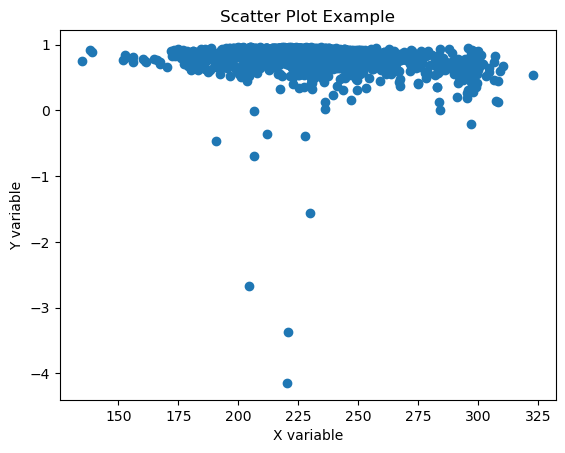

In [74]:
# Create scatter plot
plt.scatter(network_basins["lp_freq"], network_basins["estreams_kges"])

# Add labels and title
plt.xlabel("X variable")
plt.ylabel("Y variable")
plt.title("Scatter Plot Example")

# Show the plot
plt.show()

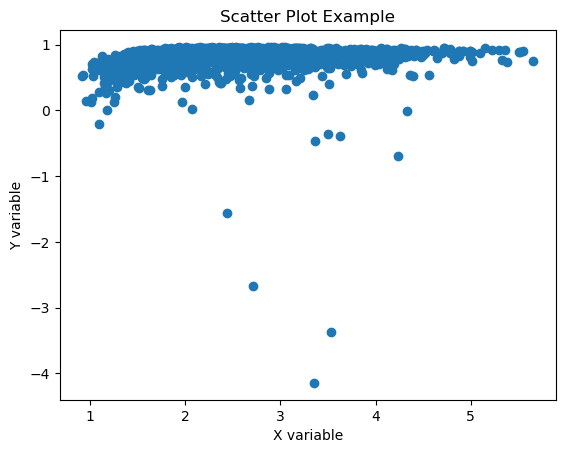

In [75]:
# Create scatter plot
plt.scatter(network_basins["p_mean"], network_basins["estreams_kges"])

# Add labels and title
plt.xlabel("X variable")
plt.ylabel("Y variable")
plt.title("Scatter Plot Example")

# Show the plot
plt.show()

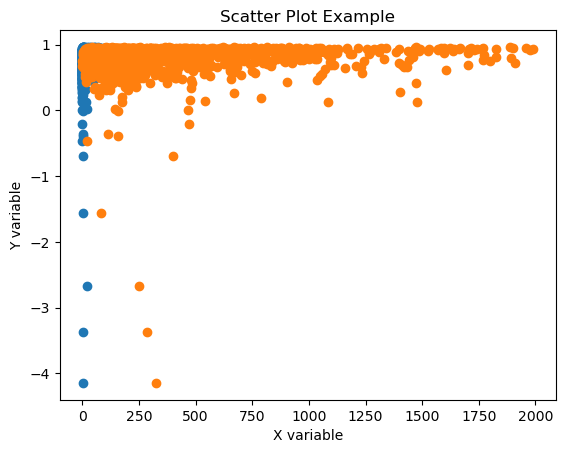

In [76]:
# Create scatter plot
plt.scatter(network_basins["stations_num_p_mean"], network_basins["estreams_kges"])
plt.scatter(network_basins["area_estreams"], network_basins["estreams_kges"])

# Add labels and title
plt.xlabel("X variable")
plt.ylabel("Y variable")
plt.title("Scatter Plot Example")

# Show the plot
plt.show()

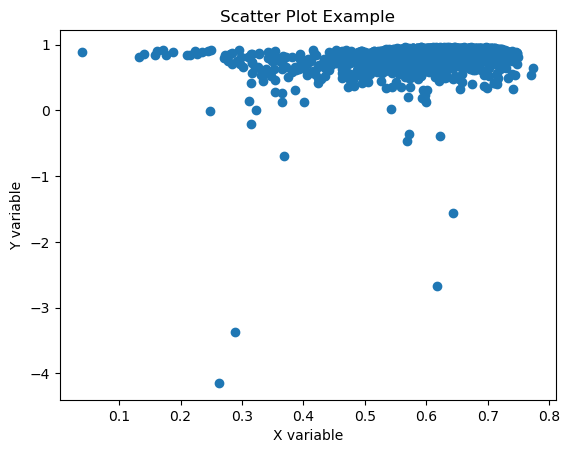

In [77]:
# Create scatter plot
plt.scatter(network_basins["ndvi_mean"], network_basins["estreams_kges"])

# Add labels and title
plt.xlabel("X variable")
plt.ylabel("Y variable")
plt.title("Scatter Plot Example")

# Show the plot
plt.show()

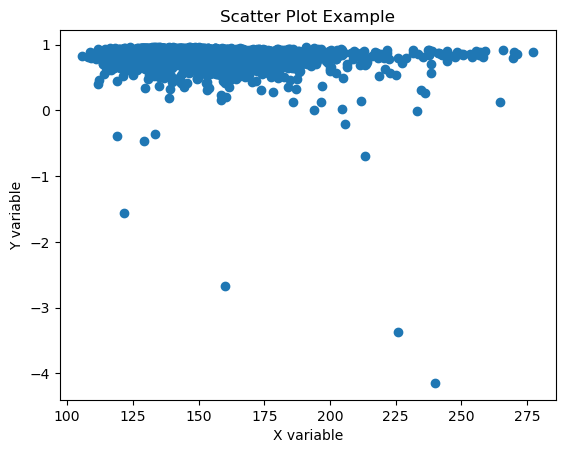

In [78]:
# Create scatter plot
plt.scatter(network_basins["hfd_mean"], network_basins["estreams_kges"])

# Add labels and title
plt.xlabel("X variable")
plt.ylabel("Y variable")
plt.title("Scatter Plot Example")

# Show the plot
plt.show()

23 variables with |r| > 0.14


,estreams_kges
estreams_kges,1.000000
camels_kges,0.664923
delta_kge,0.462937
stations_num_t_mean,0.447110
stations_num_p_mean,0.411887
ndvi_mean,0.301065
lulc_2006_Agric,0.296223
lulc_2006_urban,0.223366
p_mean,0.209377
lai_mean,0.189352


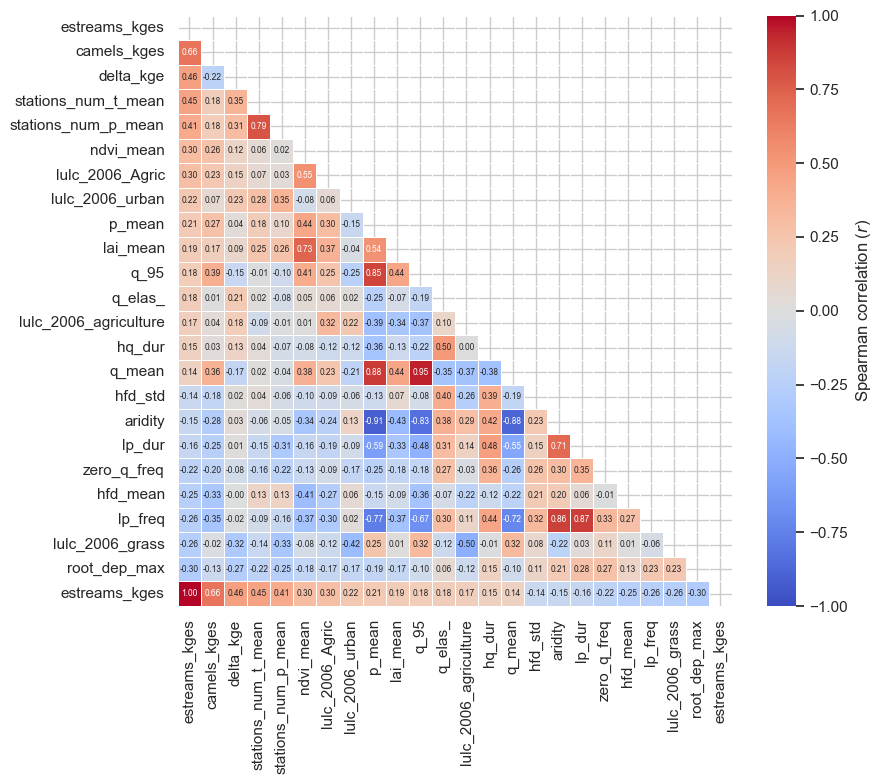

In [108]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Example threshold (you can change it)
threshold = 0.14
network_basins["delta_kge"] = network_basins["diff"]
network_basins["q_elas_"] = network_basins["q_elas_Sankarasubramanian"]

columns_corr=["estreams_kges", "camels_kges", "delta_kge", 'q_mean',
       'q_runoff_ratio', 'q_elas_', 'slope_sawicz',
       'baseflow_index', 'hfd_mean', 'hfd_std', 'q_5', 'q_95', 'hq_freq',
       'hq_dur', 'lq_freq', 'lq_dur', 'zero_q_freq', 'p_mean', 'pet_mean',
       'aridity', 
       'p_seasonality', 'frac_snow', 'hp_freq', 'hp_dur', 'hp_time', 'lp_freq',
       'lp_dur', 'lp_time', 'ele_mt_max', 'ele_mt_mean', 'ele_mt_min',
       'slp_dg_mean', 'flat_area_fra', 'steep_area_fra', 'elon_ratio',
       'strm_dens', 'root_dep_mean', 'root_dep_max', 'root_dep_min',
       'soil_tawc_mean', 'soil_fra_sand_mean', 'soil_fra_silt_mean',
       'soil_fra_clay_mean', 'soil_fra_grav_mean', 'soil_bd_mean',
       'soil_oc_mean', 'lai_mean', 'ndvi_mean', 'lulc_2006_urban',
       'lulc_2006_NonIrriAgri', 'lulc_2006_Agric', 'lulc_2006_forest',
       'lulc_2006_grass', 'lulc_2006_agriculture', 'dam_num', 'res_num',
       'lakes_num', 'lakes_tot_area', 'lakes_tot_vol', 'sno_cov_mean',
       'stations_num_p_mean', 'stations_num_t_mean'
       ]

# Compute correlations (Spearman)
corr = network_basins.loc[:, columns_corr].corr(method="spearman")

# Filter only correlations with estreams_kges above threshold
corr_filtered = corr[["estreams_kges"]].copy()
corr_filtered = corr_filtered[abs(corr_filtered["estreams_kges"]) > threshold]
corr_filtered = corr_filtered.sort_values(by="estreams_kges", ascending=False)

print(f"{len(corr_filtered)} variables with |r| > {threshold}")
display(corr_filtered)

# Optional: full correlation matrix among filtered variables (for plotting)
vars_to_keep = corr_filtered.index.tolist()
corr_subset = corr.loc[vars_to_keep + ["estreams_kges"], vars_to_keep + ["estreams_kges"]]

# Mask upper triangle for half-heatmap
mask = np.triu(np.ones_like(corr_subset, dtype=bool))

# Plot 
plt.figure(figsize=(9, 8))
sns.heatmap(
    corr_subset,
    mask=mask,
    cmap="coolwarm",
    vmin=-1, vmax=1,
    annot=True, fmt=".2f",
    linewidths=0.5,
    annot_kws={"size": 6}, 

    cbar_kws={"label": "Spearman correlation ($r$)"}
)
plt.tight_layout()

plt.savefig("results/figs/S5_correlations_above_15.pdf", dpi = 300, bbox_inches='tight')
plt.savefig("results/figs/S5_correlations_above_15.png", dpi = 300, bbox_inches='tight')

plt.show()


In [85]:
import pandas as pd
import numpy as np
from scipy.stats import spearmanr

threshold = 0.14

network_basins["delta_kge"] = network_basins["diff"]
network_basins["q_elas_"] = network_basins["q_elas_Sankarasubramanian"]

columns_corr = [
    "estreams_kges", "camels_kges", "delta_kge", 'q_mean',
    'q_runoff_ratio', 'q_elas_', 'slope_sawicz',
    'baseflow_index', 'hfd_mean', 'hfd_std', 'q_5', 'q_95', 'hq_freq',
    'hq_dur', 'lq_freq', 'lq_dur', 'zero_q_freq', 'p_mean', 'pet_mean',
    'aridity', 'p_seasonality', 'frac_snow', 'hp_freq', 'hp_dur', 'hp_time',
    'lp_freq', 'lp_dur', 'lp_time', 'ele_mt_max', 'ele_mt_mean', 'ele_mt_min',
    'slp_dg_mean', 'flat_area_fra', 'steep_area_fra', 'elon_ratio',
    'strm_dens', 'root_dep_mean', 'root_dep_max', 'root_dep_min',
    'soil_tawc_mean', 'soil_fra_sand_mean', 'soil_fra_silt_mean',
    'soil_fra_clay_mean', 'soil_fra_grav_mean', 'soil_bd_mean',
    'soil_oc_mean', 'lai_mean', 'ndvi_mean', 'lulc_2006_urban',
    'lulc_2006_NonIrriAgri', 'lulc_2006_Agric', 'lulc_2006_forest',
    'lulc_2006_grass', 'lulc_2006_agriculture', 'dam_num', 'res_num',
    'lakes_num', 'lakes_tot_area', 'lakes_tot_vol', 'sno_cov_mean',
    'stations_num_p_mean', 'stations_num_t_mean'
]

def significance_stars(p):
    if np.isscalar(p):
        pass
    else:
        p = p[0]  # in case it's an array
    if np.isnan(p):
        return "ns"
    if p < 0.001:
        return '***'
    elif p < 0.01:
        return '**'
    elif p < 0.05:
        return '*'
    else:
        return 'ns'

target_vars = ["camels_kges", "estreams_kges", "delta_kge"]
rows = []

for col in columns_corr:
    row = {"variable": col}
    for target in target_vars:
        valid = network_basins[[col, target]].dropna()
        if len(valid) > 2:
            rho, p = spearmanr(valid[col], valid[target])
            # Ensure scalar output
            if isinstance(rho, np.ndarray):
                rho = rho[0, 1]
                p = p[0, 1]
            row[f"{target}_rho"] = rho
            row[f"{target}_sig"] = significance_stars(p)
        else:
            row[f"{target}_rho"] = np.nan
            row[f"{target}_sig"] = "ns"
    rows.append(row)

results_df = pd.DataFrame(rows).set_index("variable")

results_df = results_df.reindex(
    results_df["estreams_kges_rho"].abs().sort_values(ascending=False).index
)

results_df.to_csv("results/correlations_camels_estreams_delta_with_significance.csv", float_format="%.3f")

In [87]:
from scipy.stats import wilcoxon

# Remove NaNs
mask = network_basins[["estreams_kges", "camels_kges"]].dropna()

# Paired non-parametric test
stat, p = wilcoxon(mask["camels_kges"], mask["estreams_kges"],  alternative="greater")

print(f"Median CAMELS   = {mask['camels_kges'].median():.3f}")
print(f"Median EStreams = {mask['estreams_kges'].median():.3f}")

print(f"Wilcoxon statistic = {stat:.3f}, p = {p:.3e}")


Median CAMELS   = 0.891
Median EStreams = 0.875
Wilcoxon statistic = 2377437.000, p = 1.838e-47


In [88]:
# Adjust it for the figures
network_basins['color'] = pd.factorize(network_basins['gauge_country'])[0]

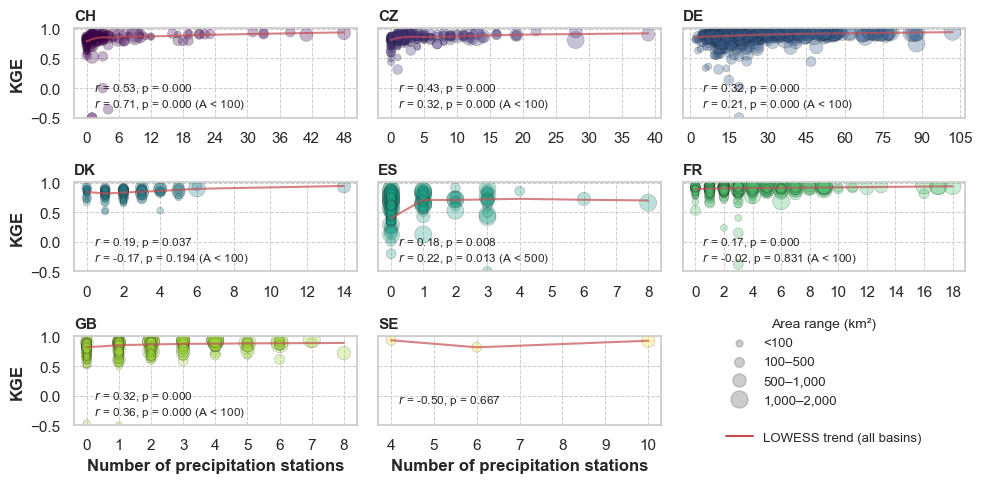

In [107]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# Set Seaborn style
sns.set(style="whitegrid", font_scale=1.0)

df = network_basins.copy()

# Clip values
df["estreams_kges"] = df["estreams_kges"].clip(lower=-0.5, upper=1.0)

# Define area bins and labels (same logic as your size scaling)
area_bins = [0, 100, 500, 1000, 2000]
area_labels = ["<100", "100–500", "500–1,000", "1,000–2,000"]
df["area_range"] = pd.cut(df["area_estreams"], bins=area_bins, labels=area_labels, right=False)

# Get unique color groups
groups = df['color'].unique()
n_groups = len(groups)

# Map color to country
color_to_country = df.drop_duplicates('color').set_index('color')['gauge_country'].to_dict()

# Professional palette
cmap = cm.get_cmap("viridis", n_groups)
new_colors = [mcolors.to_hex(cmap(i)) for i in range(n_groups)]
group_to_color = dict(zip(groups, new_colors))

# --- Area-based marker size function ---
def get_size(area):
    """Return circle size depending on area range."""
    if area < 100:
        return 25
    elif 100 <= area < 500:
        return 50
    elif 500 <= area < 1000:
        return 90
    elif 1000 <= area < 2000:
        return 150

df["scaled_size"] = df["area_estreams"].apply(get_size)

# --- Subplots ---
n_cols = 3
n_rows = (n_groups + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5), sharex=False, sharey=True)
axes = axes.flatten()

for i, color in enumerate(groups):
    group_df = df[df['color'] == color]
    country = color_to_country[color]
    plot_color = group_to_color[color]
    ax = axes[i]

    # --- Scatterplot with scaled size ---
    sns.scatterplot(
        ax=ax,
        x=group_df["stations_num_p_mean"],
        y=group_df["estreams_kges"],
        color=plot_color,
        edgecolor='k',
        linewidth=0.4,
        s=group_df["scaled_size"],
        alpha=0.3,
        marker='o',
        legend=False
    )

    # --- LOWESS line (computed on full group) ---
    sns.regplot(
        ax=ax,
        x=group_df["stations_num_p_mean"],
        y=group_df["estreams_kges"],
        scatter=False,
        lowess=True,
        color="r",
        line_kws={'lw': 1.5, 'alpha': 0.7},
    )

    # --- Correlations: overall and per area range ---
    rho_all, pval_all = spearmanr(group_df["stations_num_p_mean"], group_df["estreams_kges"], nan_policy="omit")
    # --- Compute correlations (all and A<100) ---
    text_lines = []

    # All basins
    rho_all, p_all = spearmanr(group_df["stations_num_p_mean"], group_df["estreams_kges"], nan_policy="omit")
    # --- Compute correlations (all and A < 100, or A < 500 if too few) ---
    text_lines = []

    # All basins
    rho_all, p_all = spearmanr(group_df["stations_num_p_mean"], group_df["estreams_kges"], nan_policy="omit")
    text_lines.append(f"$r$ = {rho_all:.2f}, p = {p_all:.3f}")

    # Try A < 100; if too few, use A < 500
    sub = group_df[group_df["area_estreams"] < 100]
    label_used = "(A < 100)"
    if len(sub) < 4:
        sub = group_df[group_df["area_estreams"] < 500]
        label_used = "(A < 500)"

    if len(sub) > 3:
        rho_small, p_small = spearmanr(sub["stations_num_p_mean"], sub["estreams_kges"], nan_policy="omit")
        text_lines.append(f"$r$ = {rho_small:.2f}, p = {p_small:.3f} {label_used}")
    else:
        text_lines.append(f" ")

    # Add text box to the plot
    axes[i].text(
        0.07, 0.07,
        "\n".join(text_lines),
        transform=axes[i].transAxes,
        fontsize=8.5,
        ha='left',
        va='bottom',
        bbox=dict(boxstyle="round,pad=0.25", facecolor="none", alpha=0.7, edgecolor="none")
    )


    # --- Titles and axis labels ---
    ax.set_title(f"{country}", fontsize=11, fontweight="bold", loc="left")
    if i // n_cols == n_rows - 1:
        ax.set_xlabel("Number of precipitation stations", fontweight="bold")
    else:
        ax.set_xlabel("")
    if i % n_cols == 0:
        ax.set_ylabel("KGE", fontweight="bold")
    else:
        ax.set_ylabel("")

    ax.set_ylim(-0.5, 1.01)
    ax.xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    ax.set_yticks([-0.5, 0, 0.5, 1.0])
    ax.grid(True, which='both', linestyle='--', linewidth=0.7)

# --- Legend (reuse empty subplot if available) ---
if len(axes) > n_groups:
    legend_ax = axes[n_groups]
    legend_ax.axis("off")

    legend_handles = [
        plt.scatter([], [], s=25, color="gray", alpha=0.4, label="<100"),
        plt.scatter([], [], s=50, color="gray", alpha=0.4, label="100–500"),
        plt.scatter([], [], s=90, color="gray", alpha=0.4, label="500–1,000"),
        plt.scatter([], [], s=150, color="gray", alpha=0.4, label="1,000–2,000"),
        plt.scatter([], [], s=150, color="none", alpha=0.4, label=" "),
        Line2D([0], [0], color='r', lw=1.5, linestyle='-', label='LOWESS trend (all basins)')
    ]

    legend_ax.legend(
        handles=legend_handles,
        title="Area range (km²)",
        loc="center",
        fontsize=9.5,
        title_fontsize=10,
        frameon=False,
        ncol=1
    )

# --- Delete unused axes (if any) ---
for j in range(n_groups + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("results/figs/7_kge_n_stations.pdf", dpi=300, bbox_inches='tight')
plt.savefig("results/figs/7_kge_n_stations.png", dpi=300, bbox_inches='tight')

plt.show()


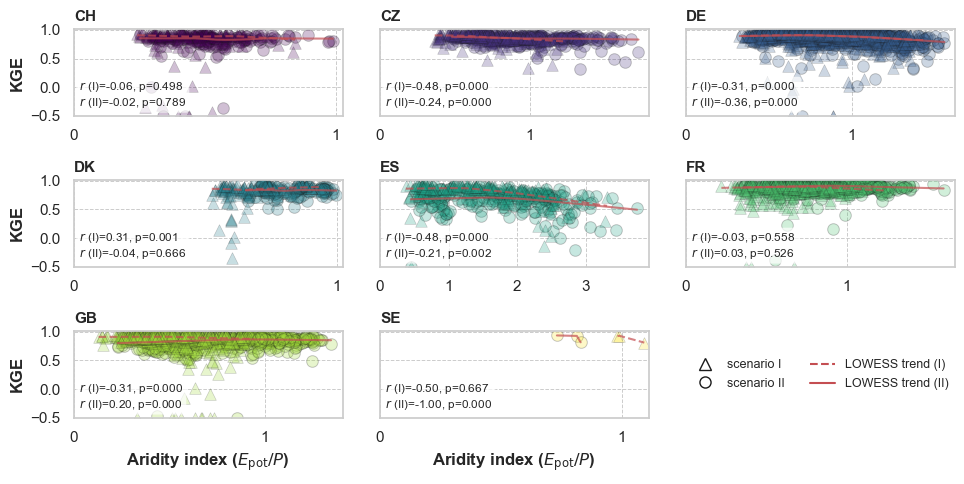

In [106]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# Set Seaborn style
sns.set(style="whitegrid", font_scale=1.0)

df = network_basins.copy()

# Clip values
df["estreams_kges"] = df["estreams_kges"].clip(lower=-0.5, upper=1.0)
df["camels_kges"] = df["camels_kges"].clip(lower=-0.5, upper=1.0)

# Get unique color groups
groups = df['color'].unique()
n_groups = len(groups)

# Map each color to its corresponding gauge_country
color_to_country = df.drop_duplicates('color').set_index('color')['gauge_country'].to_dict()

# Generate professional color palette
cmap = cm.get_cmap("viridis", n_groups)
new_colors = [mcolors.to_hex(cmap(i)) for i in range(n_groups)]
group_to_color = dict(zip(groups, new_colors))

# Set up subplot grid
n_cols = 3
n_rows = (n_groups + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5), sharex=False, sharey=True)
axes = axes.flatten()

for i, color in enumerate(groups):
    group_df = df[df['color'] == color]
    country = color_to_country[color]
    plot_color = group_to_color[color]

    # --- Compute Spearman correlations ---
    rho_e, pval_e = spearmanr(group_df["aridity_estreams"], group_df["estreams_kges"], nan_policy="omit")
    rho_c, pval_c = spearmanr(group_df["aridity_camels"], group_df["camels_kges"], nan_policy="omit")

    # --- Plot points ---
    sns.scatterplot(
        ax=axes[i],
        x=group_df["aridity_estreams"],
        y=group_df["estreams_kges"],
        color=plot_color,
        edgecolor='k',
        s=70,
        alpha=0.25,
        marker='o',
        legend=False
    )

    sns.scatterplot(
        ax=axes[i],
        x=group_df["aridity_camels"],
        y=group_df["camels_kges"],
        color=plot_color,
        edgecolor='k',
        linewidth=0.4,
        s=70,
        alpha=0.25,
        marker='^',
        legend=False
    )

    # --- Add LOWESS trend lines ---
    sns.regplot(
        ax=axes[i],
        x=group_df["aridity_estreams"],
        y=group_df["estreams_kges"],
        scatter=False,
        lowess=True,
        color="r",
        line_kws={'lw': 1.5, 'alpha': 0.7},
    )
 
    sns.regplot(
        ax=axes[i],
        x=group_df["aridity_camels"],
        y=group_df["camels_kges"],
        scatter=False,
        lowess=True,
        color="r",
        line_kws={'lw': 1.5, 'alpha': 0.7, 'linestyle': '--'},
    )

    # --- Title and correlation text ---
    axes[i].set_title(f"{country}", fontsize=11, fontweight="bold", loc="left")
    axes[i].text(
        0.02, 0.07,
        f"$r$ (I)={rho_c:.2f}, p={pval_c:.3f}\n"
        f"$r$ (II)={rho_e:.2f}, p={pval_e:.3f}",
        transform=axes[i].transAxes,
        fontsize=8.5,
        ha='left',
        va='bottom',
        bbox=dict(boxstyle="round,pad=0.25", facecolor="white", alpha=0.7, edgecolor="none")
    )

    # --- Axis formatting ---
    if i // n_cols == n_rows - 1:
        axes[i].set_xlabel(r"Aridity index ($E_{\mathrm{pot}}/P$)", fontweight="bold")
    else:
        axes[i].set_xlabel("")
    if i % n_cols == 0:
        axes[i].set_ylabel("KGE", fontweight="bold")
    else:
        axes[i].set_ylabel("")

    axes[i].set_ylim(-0.5, 1.01)
    axes[i].set_xlim(0, )
    axes[i].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))
    axes[i].set_yticks([-0.5, 0, 0.5, 1.0])
    axes[i].grid(True, which='both', linestyle='--', linewidth=0.7)

# --- Place legend inside empty subplot (e.g., 9th slot) ---
if len(axes) > n_groups:
    legend_ax = axes[n_groups]
    legend_ax.axis("off")

    legend_elements = [
        Line2D([0], [0], marker='^', color='k', label='scenario I',
               markerfacecolor='none', markersize=8, linestyle='None', linewidth=0.5),
        Line2D([0], [0], marker='o', color='k', label='scenario II',
               markerfacecolor='none', markersize=8, linestyle='None', linewidth=0.5),
        Line2D([0], [0], color='r', lw=1.5, linestyle='--', label='LOWESS trend (I)'),
        Line2D([0], [0], color='r', lw=1.5, linestyle='-', label='LOWESS trend (II)')
    ]

    legend_ax.legend(
        handles=legend_elements,
        loc="center",
        fontsize=9,
        title_fontsize=10,
        frameon=False,
        ncol=2
    )

# --- Delete remaining unused axes ---
for j in range(n_groups + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("results/figs/8_KGE_aridity_scenario_I_II_trend.pdf", dpi=300, bbox_inches='tight')
plt.savefig("results/figs/8_KGE_aridity_scenario_I_II_trend.png", dpi=300, bbox_inches='tight')

plt.show()


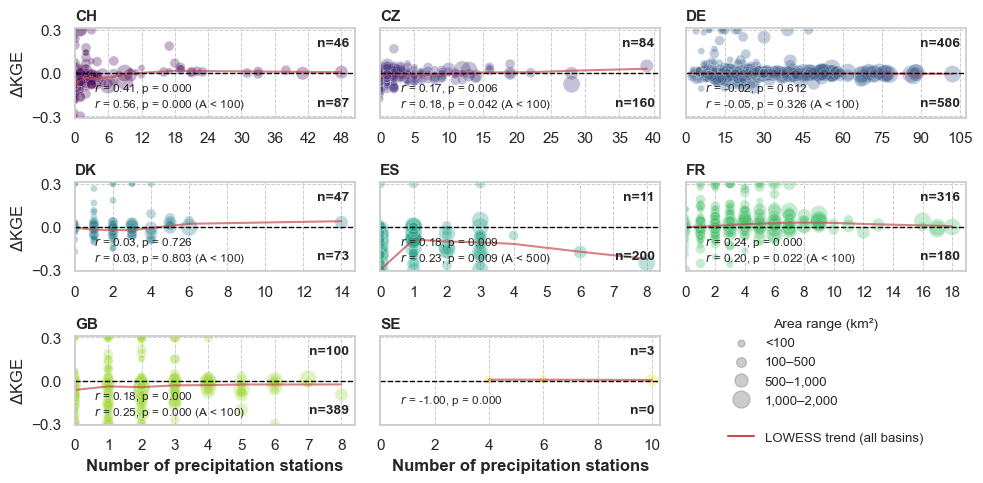

In [105]:
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import matplotlib.cm as cm
import matplotlib.colors as mcolors
import numpy as np
import pandas as pd
from scipy.stats import spearmanr
from matplotlib.lines import Line2D

# Set Seaborn style
sns.set(style="whitegrid", font_scale=1.0)

df = network_basins.copy()

# Clip values
df["diff"] = df["diff"].clip(lower=-0.3, upper=0.3)

# Define area bins and labels (same logic as your size scaling)
area_bins = [0, 100, 500, 1000, 2000]
area_labels = ["<100", "100–500", "500–1,000", "1,000–2,000"]
df["area_range"] = pd.cut(df["area_estreams"], bins=area_bins, labels=area_labels, right=False)

# Get unique color groups
groups = df['color'].unique()
n_groups = len(groups)

# Map color to country
color_to_country = df.drop_duplicates('color').set_index('color')['gauge_country'].to_dict()

# Professional palette
cmap = cm.get_cmap("viridis", n_groups)
new_colors = [mcolors.to_hex(cmap(i)) for i in range(n_groups)]
group_to_color = dict(zip(groups, new_colors))

# --- Area-based marker size function ---
def get_size(area):
    """Return circle size depending on area range."""
    if area < 100:
        return 25
    elif 100 <= area < 500:
        return 50
    elif 500 <= area < 1000:
        return 90
    elif 1000 <= area < 2000:
        return 150

df["scaled_size"] = df["area_estreams"].apply(get_size)

# --- Subplots ---
n_cols = 3
n_rows = (n_groups + n_cols - 1) // n_cols
fig, axes = plt.subplots(n_rows, n_cols, figsize=(10, 5), sharex=False, sharey=True)
axes = axes.flatten()

for i, color in enumerate(groups):
    group_df = df[df['color'] == color]
    country = color_to_country[color]
    plot_color = group_to_color[color]
    ax = axes[i]

    # --- Scatterplot with scaled size ---
    sns.scatterplot(
        ax=ax,
        x=group_df["stations_num_p_mean"],
        y=group_df["diff"],
        color=plot_color,
        edgecolor='white',
        s=group_df["scaled_size"],
        alpha=0.3,
        marker='o',
        legend=False
    )

    # --- LOWESS line (computed on full group) ---
    sns.regplot(
        ax=ax,
        x=group_df["stations_num_p_mean"],
        y=group_df["diff"],
        scatter=False,
        lowess=True,
        color="r",
        line_kws={'lw': 1.5, 'alpha': 0.7},
    )

    # --- Correlations: overall and per area range ---
    rho_all, pval_all = spearmanr(group_df["stations_num_p_mean"], group_df["diff"], nan_policy="omit")
    # --- Compute correlations (all and A<100) ---
    text_lines = []

    # All basins
    rho_all, p_all = spearmanr(group_df["stations_num_p_mean"], group_df["diff"], nan_policy="omit")
    # --- Compute correlations (all and A < 100, or A < 500 if too few) ---
    text_lines = []

    # All basins
    rho_all, p_all = spearmanr(group_df["stations_num_p_mean"], group_df["diff"], nan_policy="omit")
    text_lines.append(f"$r$ = {rho_all:.2f}, p = {p_all:.3f}")

    # Try A < 100; if too few, use A < 500
    sub = group_df[group_df["area_estreams"] < 100]
    label_used = "(A < 100)"
    if len(sub) < 4:
        sub = group_df[group_df["area_estreams"] < 500]
        label_used = "(A < 500)"

    if len(sub) > 3:
        rho_small, p_small = spearmanr(sub["stations_num_p_mean"], sub["diff"], nan_policy="omit")
        text_lines.append(f"$r$ = {rho_small:.2f}, p = {p_small:.3f} {label_used}")
    else:
        text_lines.append(f" ")

    # Add text box to the plot
    axes[i].text(
        0.07, 0.07,
        "\n".join(text_lines),
        transform=axes[i].transAxes,
        fontsize=8.5,
        ha='left',
        va='bottom',
        bbox=dict(boxstyle="round,pad=0.25", facecolor="none", alpha=0.7, edgecolor="none")
    )


    # --- Titles and axis labels ---
    ax.set_title(f"{country}", fontsize=11, fontweight="bold", loc="left")
    if i // n_cols == n_rows - 1:
        ax.set_xlabel("Number of precipitation stations", fontweight="bold")
    else:
        ax.set_xlabel("")
    if i % n_cols == 0:
        axes[i].set_ylabel(r"$\Delta$KGE")
    else:
        ax.set_ylabel("")

    axes[i].set_ylim(-0.31, 0.31)
    axes[i].set_xlim(left=0)
    axes[i].xaxis.set_major_locator(mticker.MaxNLocator(integer=True))

    axes[i].axhline(0, color='black', linestyle='--', linewidth=1)

    axes[i].set_yticks([-0.3, 0, 0.3])

    axes[i].grid(True, which='both', linestyle='--', linewidth=0.7)

    # Annotate counts
    n_above = (group_df['diff'] > 0).sum()
    n_below = (group_df['diff'] < 0).sum()

    axes[i].text(
        0.98, 0.9,
        f"n={n_above}",
        transform=axes[i].transAxes,
        ha="right", va="top",
        fontsize=10, fontweight="bold"
    )

    axes[i].text(
        0.98, 0.1,
        f"n={n_below}",
        transform=axes[i].transAxes,
        ha="right", va="bottom",
        fontsize=10, fontweight="bold"
    )


# --- Legend (reuse empty subplot if available) ---
if len(axes) > n_groups:
    legend_ax = axes[n_groups]
    legend_ax.axis("off")

    legend_handles = [
        plt.scatter([], [], s=25, color="gray", alpha=0.4, label="<100"),
        plt.scatter([], [], s=50, color="gray", alpha=0.4, label="100–500"),
        plt.scatter([], [], s=90, color="gray", alpha=0.4, label="500–1,000"),
        plt.scatter([], [], s=150, color="gray", alpha=0.4, label="1,000–2,000"),
        plt.scatter([], [], s=150, color="none", alpha=0.4, label=" "),
        Line2D([0], [0], color='r', lw=1.5, linestyle='-', label='LOWESS trend (all basins)')
    ]

    legend_ax.legend(
        handles=legend_handles,
        title="Area range (km²)",
        loc="center",
        fontsize=9.5,
        title_fontsize=10,
        frameon=False,
        ncol=1
    )

# --- Delete unused axes (if any) ---
for j in range(n_groups + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.savefig("results/figs/S6_kge_scatters_pstations.pdf", dpi=300, bbox_inches='tight')
plt.savefig("results/figs/S6_kge_scatters_pstations.png", dpi=300, bbox_inches='tight')

plt.show()
